# 11 - Visualization and Reporting

Theme: **Cameroonian International Migration Trends (2015-2024): Destinations, Entry Reasons and Post-Arrival Trajectories Across Available Reference Years**.

This notebook creates final portfolio-ready PNG figures in `outputs/figures/`. The charts are designed to support the three analytical questions while keeping each indicator type clearly separated.


## Methodological Positioning

The `period` field is an operational grouping used to structure comparisons across the available data period. It should not be interpreted as a causal pandemic effect variable.


In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [24]:
PROJECT_ROOT = Path('..')

ANALYTICAL_PATH = PROJECT_ROOT / 'data' / 'processed' / 'analytical'
FIGURES_PATH = PROJECT_ROOT / 'outputs' / 'figures'

FIGURES_PATH.mkdir(parents=True, exist_ok=True)

period_order = ['2015-2019', '2020-2021', '2022-2024']

In [25]:
def prepare_table(df):
    df = df.copy()
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
    df['value'] = pd.to_numeric(df['value'], errors='coerce').fillna(0)

    for col in ['source', 'destination_country', 'period', 'measure_type', 'reason']:
        if col in df.columns:
            df[col] = df[col].astype('string').str.strip()

    return df


def assign_period(year):
    """Assign neutral descriptive periods based on the available year."""
    if pd.isna(year):
        return 'outside_scope'
    year = int(year)
    if 2015 <= year <= 2019:
        return '2015-2019'
    if 2020 <= year <= 2021:
        return '2020-2021'
    if 2022 <= year <= 2024:
        return '2022-2024'
    return 'outside_scope'


def save_figure(file_name):
    """Save the current Matplotlib figure as a high-resolution PNG."""
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / file_name, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [26]:
destinations = prepare_table(pd.read_csv(ANALYTICAL_PATH / 'destinations_master.csv'))
entry_reasons = prepare_table(pd.read_csv(ANALYTICAL_PATH / 'entry_reasons_master.csv'))
post_arrival = prepare_table(pd.read_csv(ANALYTICAL_PATH / 'post_arrival_master.csv'))

undesa_destinations = destinations[
    (destinations['source'].str.lower() == 'undesa')
    & (destinations['measure_type'].str.lower() == 'stock')
].copy()

eurostat_entry = entry_reasons[
    (entry_reasons['source'].str.lower() == 'eurostat')
    & (entry_reasons['measure_type'].str.lower() == 'permit')
].copy()

# Keep the existing `period` variable name, but recode it with neutral labels.
eurostat_entry['period'] = eurostat_entry['year'].apply(assign_period)
eurostat_entry = eurostat_entry[eurostat_entry['period'] != 'outside_scope'].copy()
eurostat_entry['period'] = pd.Categorical(
    eurostat_entry['period'],
    categories=period_order,
    ordered=True
)

eurostat_post_arrival = post_arrival[
    post_arrival['source'].str.lower() == 'eurostat'
].copy()

# Keep the existing `period` variable name, but recode it with neutral labels.
eurostat_post_arrival['period'] = eurostat_post_arrival['year'].apply(assign_period)
eurostat_post_arrival = eurostat_post_arrival[
    eurostat_post_arrival['period'] != 'outside_scope'
].copy()
eurostat_post_arrival['period'] = pd.Categorical(
    eurostat_post_arrival['period'],
    categories=period_order,
    ordered=True
)

print('Destinations:', destinations.shape)
print('Entry reasons:', entry_reasons.shape)
print('Post-arrival:', post_arrival.shape)

Destinations: (695, 11)
Entry reasons: (1595, 10)
Post-arrival: (948, 8)


## Q1 - Destination Charts Across Reference Years

Q1 uses UN DESA migrant stock data. These charts describe where migrants originating from Cameroon were estimated to be living in the selected reference years.

They should not be interpreted as annual migration arrivals or inflows.


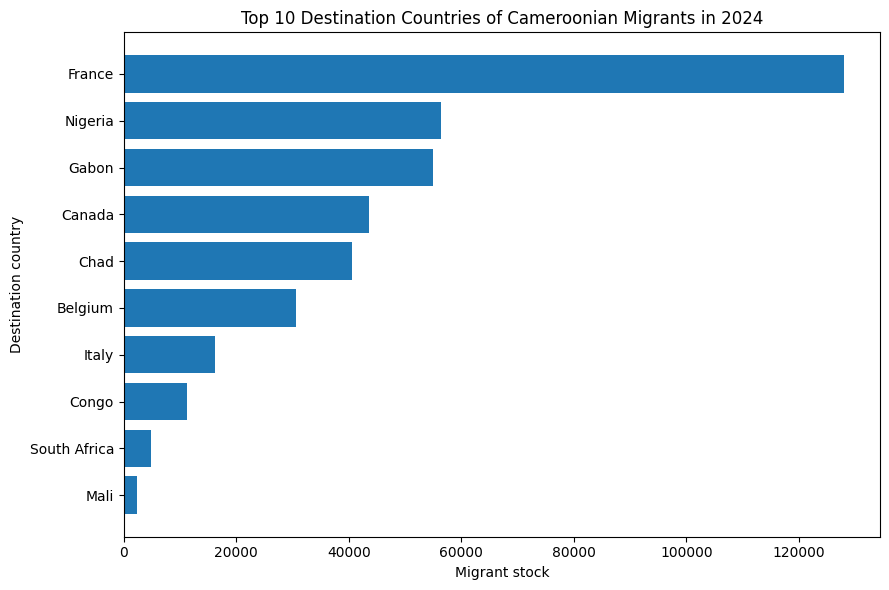

In [27]:
top_2024 = (
    undesa_destinations[undesa_destinations['year'] == 2024]
    .groupby('destination_country', as_index=False)['value']
    .sum()
    .sort_values('value', ascending=False)
    .head(10)
    .sort_values('value')
)

plt.figure(figsize=(9, 6))
plt.barh(top_2024['destination_country'], top_2024['value'])
plt.title('Top 10 Destination Countries of Cameroonian Migrants in 2024')
plt.xlabel('Migrant stock')
plt.ylabel('Destination country')
save_figure('q1_top_10_destinations_2024.png')


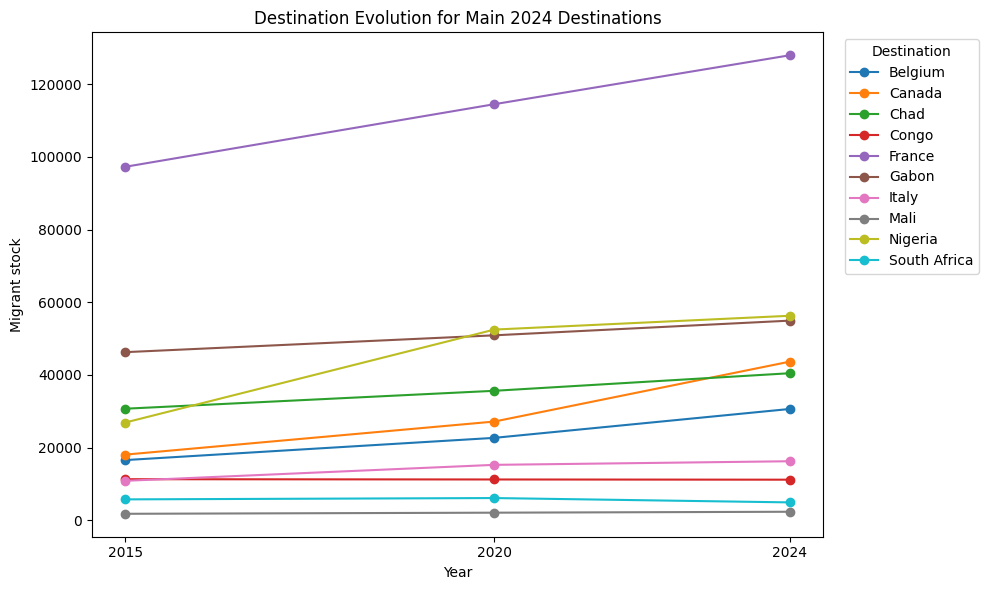

In [28]:
top_countries_2024 = top_2024['destination_country'].tolist()
destination_trends = (
    undesa_destinations[
        undesa_destinations['destination_country'].isin(top_countries_2024)
        & undesa_destinations['year'].isin([2015, 2020, 2024])
    ]
    .groupby(['year', 'destination_country'], as_index=False)['value']
    .sum()
    .pivot(index='year', columns='destination_country', values='value')
    .sort_index()
)

plt.figure(figsize=(10, 6))
for country in destination_trends.columns:
    plt.plot(destination_trends.index, destination_trends[country], marker='o', label=country)
plt.title('Destination Evolution for Main 2024 Destinations')
plt.xlabel('Year')
plt.ylabel('Migrant stock')
plt.xticks([2015, 2020, 2024])
plt.legend(title='Destination', bbox_to_anchor=(1.02, 1), loc='upper left')
save_figure('q1_destination_evolution_2015_2020_2024.png')


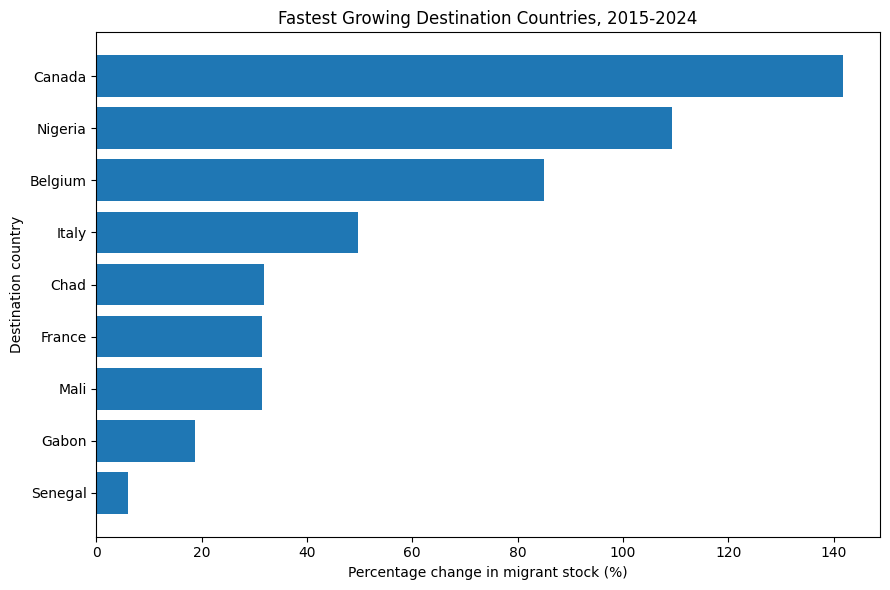

In [29]:
destination_growth = (
    undesa_destinations[undesa_destinations['year'].isin([2015, 2024])]
    .pivot_table(
        index='destination_country',
        columns='year',
        values='value',
        aggfunc='sum'
    )
    .dropna(subset=[2015, 2024])
)

destination_growth['absolute_change_2015_2024'] = (
    destination_growth[2024] - destination_growth[2015]
)

destination_growth['pct_change_2015_2024'] = (
    destination_growth['absolute_change_2015_2024'] / destination_growth[2015] * 100
)

fastest_growing_destinations = destination_growth.reset_index()

fastest_growing_destinations = fastest_growing_destinations[
    (fastest_growing_destinations[2015] >= 1000)
    & (fastest_growing_destinations['pct_change_2015_2024'] > 0)
].copy()

fastest_growing_destinations = (
    fastest_growing_destinations
    .sort_values('pct_change_2015_2024', ascending=False)
    .head(10)
    .sort_values('pct_change_2015_2024')
)

plt.figure(figsize=(9, 6))
plt.barh(
    fastest_growing_destinations['destination_country'],
    fastest_growing_destinations['pct_change_2015_2024']
)

plt.title('Fastest Growing Destination Countries, 2015-2024')
plt.xlabel('Percentage change in migrant stock (%)')
plt.ylabel('Destination country')

save_figure('q1_fastest_growing_destinations_2015_2024.png')

## Q2 - Entry Reason Charts Across Available Years

Q2 uses Eurostat first permits as the main source.

The objective is to visualize observable administrative entry reasons such as family, education, work and other reasons.

The `period` variable is used with neutral descriptive labels only: `2015-2019`, `2020-2021` and `2022-2024`. These groups are not used to estimate Covid-19 impact.

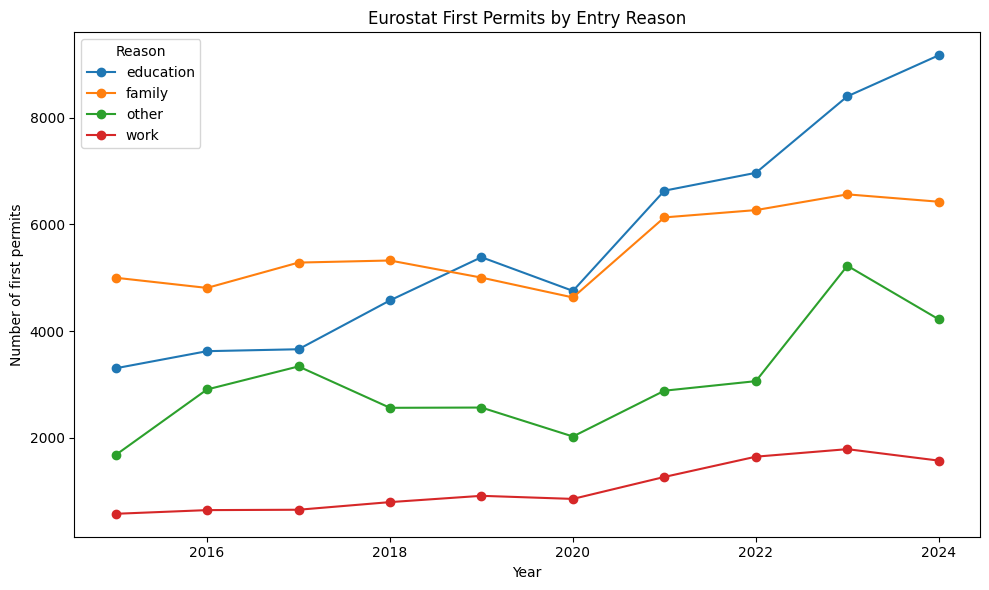

In [30]:
entry_yearly = (
    eurostat_entry.groupby(['year', 'reason'], as_index=False)['value']
    .sum()
    .pivot(index='year', columns='reason', values='value')
    .sort_index()
)

plt.figure(figsize=(10, 6))
for reason in entry_yearly.columns:
    plt.plot(entry_yearly.index, entry_yearly[reason], marker='o', label=reason)
plt.title('Eurostat First Permits by Entry Reason')
plt.xlabel('Year')
plt.ylabel('Number of first permits')
plt.legend(title='Reason')
save_figure('q2_entry_reasons_yearly_evolution.png')


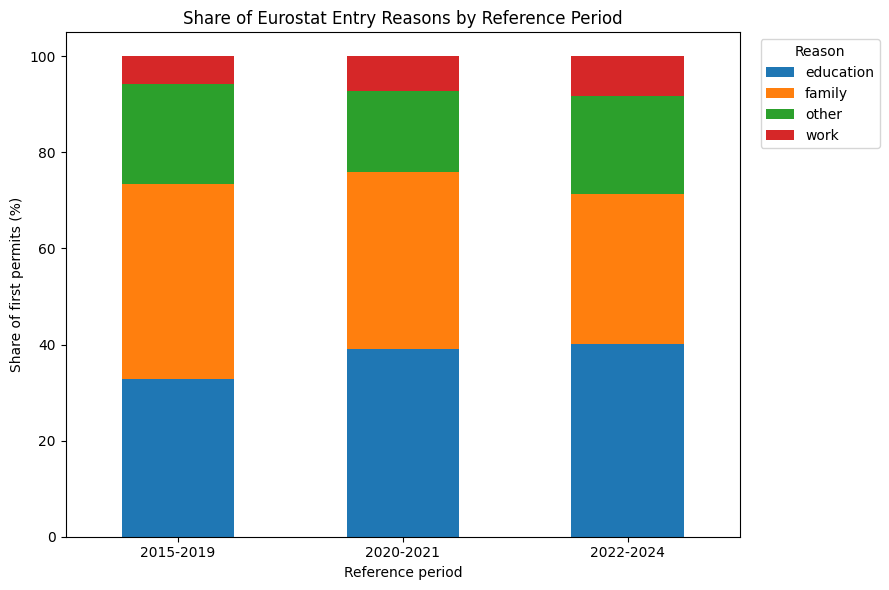

In [31]:
entry_period = (
    eurostat_entry
    .groupby(['period', 'reason'], as_index=False, observed=False)['value']
    .sum()
)

period_total = (
    entry_period
    .groupby('period', as_index=False, observed=False)['value']
    .sum()
    .rename(columns={'value': 'period_total'})
)

entry_period = entry_period.merge(period_total, on='period', how='left')
entry_period['share_pct'] = (
    entry_period['value'] / entry_period['period_total'] * 100
)

entry_share_pivot = (
    entry_period
    .pivot_table(index='period', columns='reason', values='share_pct', aggfunc='sum', observed=False)
    .reindex(period_order)
)

plt.figure(figsize=(9, 6))
entry_share_pivot.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Share of Eurostat Entry Reasons by Reference Period')
plt.xlabel('Reference period')
plt.ylabel('Share of first permits (%)')
plt.xticks(rotation=0)
plt.legend(title='Reason', bbox_to_anchor=(1.02, 1), loc='upper left')
save_figure('q2_entry_reasons_share_by_period.png')

## Q3 - Post-Arrival Charts Across Available Years

Q3 visualizations use Eurostat only for the main charts.

Post-arrival indicators are kept separate from migrant stock and first permits. The charts use the same neutral descriptive `period` groups as Q2.

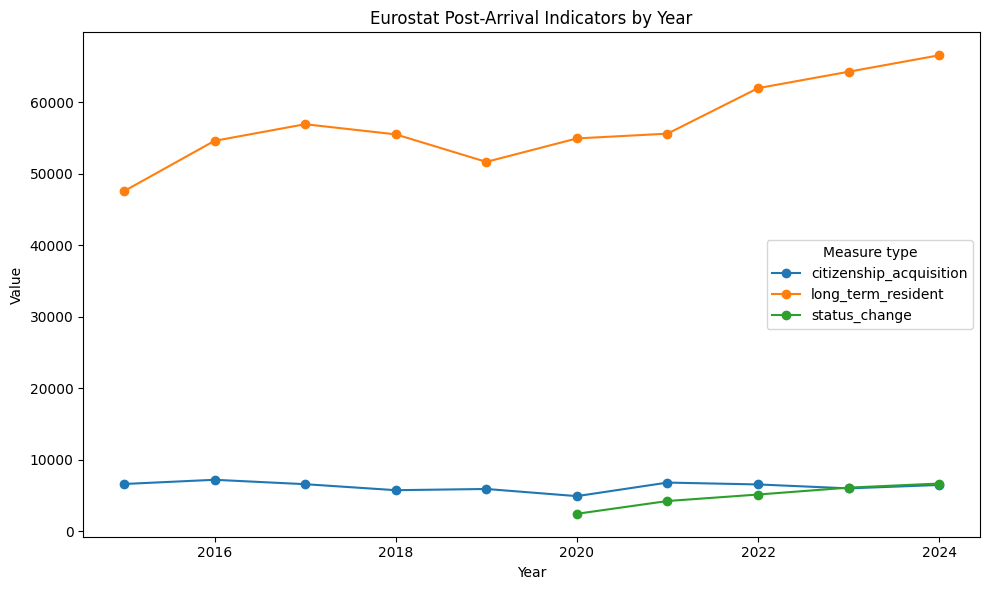

In [32]:
post_yearly = (
    eurostat_post_arrival.groupby(['year', 'measure_type'], as_index=False)['value']
    .sum()
    .pivot(index='year', columns='measure_type', values='value')
    .sort_index()
)

plt.figure(figsize=(10, 6))
for measure_type in post_yearly.columns:
    plt.plot(post_yearly.index, post_yearly[measure_type], marker='o', label=measure_type)
plt.title('Eurostat Post-Arrival Indicators by Year')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(title='Measure type')
save_figure('q3_post_arrival_indicators_by_year_eurostat.png')


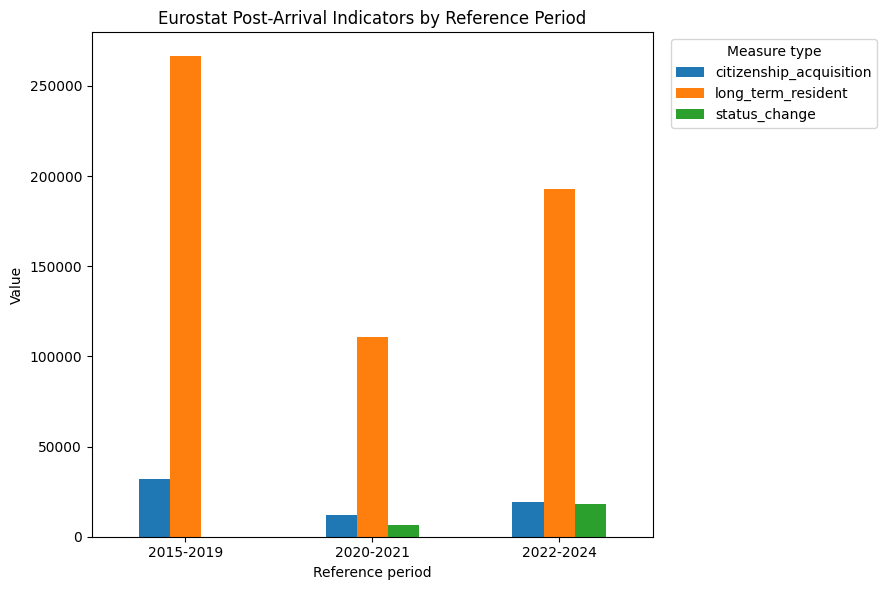

In [33]:
post_period = (
    eurostat_post_arrival
    .groupby(['period', 'measure_type'], as_index=False, observed=False)['value']
    .sum()
    .pivot_table(index='period', columns='measure_type', values='value', aggfunc='sum', observed=False)
    .reindex(period_order)
)

plt.figure(figsize=(9, 6))
post_period.plot(kind='bar', ax=plt.gca())
plt.title('Eurostat Post-Arrival Indicators by Reference Period')
plt.xlabel('Reference period')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.legend(title='Measure type', bbox_to_anchor=(1.02, 1), loc='upper left')
save_figure('q3_post_arrival_indicators_by_period_eurostat.png')

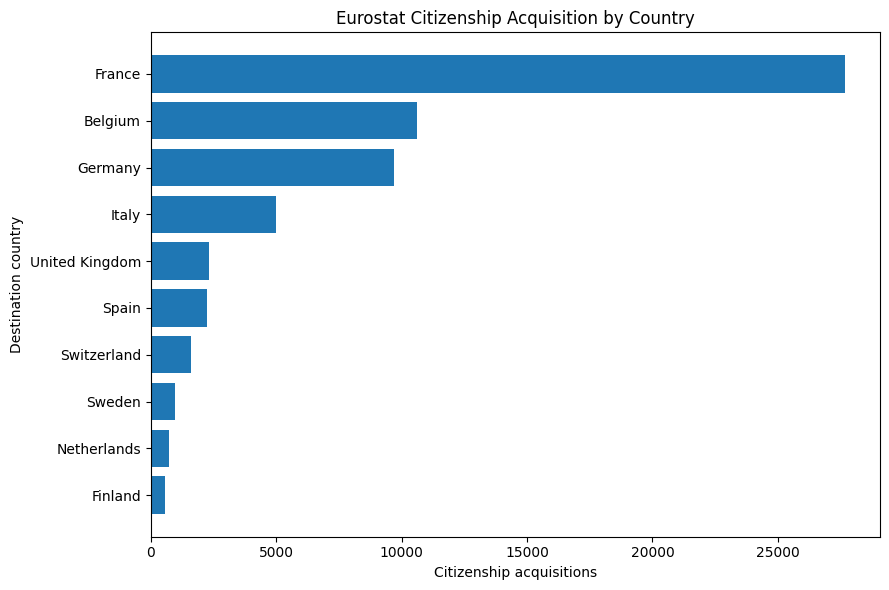

In [34]:
citizenship_country = (
    eurostat_post_arrival[
        eurostat_post_arrival['measure_type'].str.lower() == 'citizenship_acquisition'
    ]
    .groupby('destination_country', as_index=False)['value']
    .sum()
    .sort_values('value', ascending=False)
    .head(10)
    .sort_values('value')
)

plt.figure(figsize=(9, 6))
plt.barh(citizenship_country['destination_country'], citizenship_country['value'])
plt.title('Eurostat Citizenship Acquisition by Country')
plt.xlabel('Citizenship acquisitions')
plt.ylabel('Destination country')
save_figure('q3_citizenship_acquisition_by_country_eurostat.png')


## Export Summary

The notebook saves final PNG figures in `outputs/figures/` with `dpi=300`.

Main methodological cautions:

- UN DESA migrant stock is not an inflow indicator.
- Eurostat first permits are administrative entry indicators.
- Eurostat post-arrival indicators are interpreted separately from first permits and migrant stock.
- The periods `2015-2019`, `2020-2021` and `2022-2024` are descriptive reference periods.
- The project does not estimate the causal effect of Covid-19 on migration patterns.